In [126]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.transforms as transforms
import igraph as ig
import leidenalg as la
import numpy as np
from sklearn.neighbors import kneighbors_graph
import napypi
import matplotlib as mpl
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

In [56]:
# Load high-dimensional clustering results.
mimic = pd.read_csv("MIMIC_leiden_knn_clustering_scores.csv")
mimic["Dataset"] = "MIMIC"
luad = pd.read_csv("TCGA_LUAD_leiden_knn_clustering_scores.csv")
luad["Dataset"] = "TCGA-LUAD"
hancock = pd.read_csv("HANCOCK_leiden_knn_clustering_scores.csv")
hancock["Dataset"] = "HANCOCK"
all = pd.concat([mimic, luad, hancock], ignore_index=True)
all['Method'] = all['method'].str.split('_').str[0]
all["db_final"] = np.where(
    all["Method"] == "POME",
    all["db_custom"],
    all["davies_bouldin"]
)
medians = all.groupby(['Dataset', 'dim', 'Method'])[['silhouette', 'db_final']].median().reset_index()
dataset_best = medians.groupby(["Dataset", "Method"]).agg({
    "db_final": "min",
    "silhouette": "max"
}).reset_index()
dataset_best['best_sil'] = dataset_best.groupby('Dataset')['silhouette'].transform('max') == dataset_best['silhouette']
dataset_best['best_db'] = dataset_best.groupby('Dataset')['db_final'].transform('min') == dataset_best['db_final']

# 2. Count occurrences
res_sil = dataset_best[dataset_best['best_sil']].groupby('Method').size().reset_index(name='max_on_dataset')
res_sil['score'] = 'Silhouette'

res_db = dataset_best[dataset_best['best_db']].groupby('Method').size().reset_index(name='max_on_dataset')
res_db['score'] = 'Davies-Bouldin'

# 3. Combine results
aggregated_df = pd.concat([res_sil, res_db], ignore_index=True)
aggregated_df


,Method,max_on_dataset,score
0,POME,2,Silhouette
1,UMAP,1,Silhouette
2,POME,2,Davies-Bouldin
3,UMAP,1,Davies-Bouldin


In [120]:
dist_df = pd.read_csv("visualization_distance_preservation_results.csv")
clust_df = pd.read_csv("visualization_cluster_preservation_results.csv")
dist_df = dist_df[dist_df["K"]==10]
dist_df.drop(columns="K", inplace=True)
mean_dist_df = (
    dist_df.groupby(["dataset", "method", "run"], as_index=False)["jaccard_index"]
      .mean()
)
silhouette_df = (
  clust_df.groupby(["dataset", 'method', "run"], as_index=False)["silhouette"]
  .mean()
)
davies_df = (
  clust_df.groupby(["dataset", "run", "method"], as_index=False)["davies_bouldin"]
  .mean()
)
mean_dist_df = mean_dist_df.replace({"TCGA_LUAD": "TCGA-LUAD"})
silhouette_df = silhouette_df.replace({"TCGA_LUAD": "TCGA-LUAD"})
davies_df = davies_df.replace({"TCGA_LUAD": "TCGA-LUAD"})


In [121]:
# Load and visualize best clustering HANCOCK embeddings.
emb_path = "/home/wollerf/Projects/graph_based_embeddings.git/data/preprocessed/graph_based/HANCOCK/embeddings/HANCOCK_samples_32_5.tsv"
vis_path = "/home/wollerf/Projects/graph_based_embeddings.git/data/preprocessed/graph_based/HANCOCK/visualization/HANCOCK_samples_32_5.tsv"
emb_df = pd.read_csv(emb_path, sep='\t', index_col=0)
vis_df = pd.read_csv(vis_path, sep='\t', index_col=0)[["tSNE_1", "tSNE_2"]]
emb_df.index = emb_df.index.astype("str")
vis_df.index = vis_df.index.astype("str")
# Cluster 32-dim. embeddings and merge into 2D labels.
n_neighbors = int(0.05 * len(emb_df))

## 1. Process POME Embeddings
pome_adj = kneighbors_graph(
    emb_df.to_numpy(),
    n_neighbors=n_neighbors,
    mode='connectivity',
    include_self=False,
    metric='sqeuclidean', 
)

# Convert sparse matrix to igraph
sources, targets = pome_adj.nonzero()
pome_ig = ig.Graph(
    n=pome_adj.shape[0],
    edges=list(zip(sources, targets)),
    directed=False
)

# Run Leiden
pome_partition = la.find_partition(
    pome_ig,
    la.RBConfigurationVertexPartition,
    seed=42
)
pome_labels = np.array(pome_partition.membership)
pome_k = len(pome_partition)
vis_df["cluster_id"] = pome_labels

In [122]:
# Compute Kaplan-Meier per cluster
targets_df = pd.read_csv("/home/wollerf/Projects/graph_based_embeddings.git/data/input/hancock_targets.csv", index_col=0)
targets_df["cluster_id"] = pome_labels

avg_days_per_month = 365.25 / 12
targets_df["followup_months"] = np.round(targets_df["days_to_last_information"] / avg_days_per_month)

# Define event: 1 = deceased, 0 = censored
targets_df["survival_status"] = (targets_df["survival_status"] == "deceased").astype(int)
targets_df = targets_df[targets_df["cluster_id"].isin([0,4])]



In [123]:
# Perform stat. test on HANCOCK patient clusters 1-vs.-all.
cluster_pval_dict = {"cluster_id": [], "variable": [], "pvalue": [], "pvalue_bonf": [], "datatype": []}
values_path = "/home/wollerf/Projects/graph_based_embeddings.git/data/input/hancock_wo_targets_graph.tsv"
values_df = pd.read_csv(values_path, sep='\t', index_col=0)
cont_vars = values_df.index[values_df["type"] == "cont"].tolist()
cat_vars = values_df.index[values_df["type"] == "cat"].tolist()
values_df.drop(columns="type", inplace=True)
values_df = values_df.T.copy()
values_df.index = values_df.index.astype("str")
joint_values = values_df.join(vis_df, how="inner")
joint_values.drop(columns=["tSNE_1", "tSNE_2"], inplace=True)
# Iterate over all clusters and perform 1-vs.all-test
for id in range(pome_k):
    cluster_values = joint_values.copy()
    cluster_values["cluster_id"] = (cluster_values["cluster_id"] == id).astype(int)
    cat_values = cluster_values[cat_vars + ["cluster_id"]].T.copy()
    cat_mat = cat_values.to_numpy()
    cont_values = cluster_values[cont_vars].T.copy()
    cont_mat = cont_values.to_numpy()
    binary_mat = np.zeros((1, 763))
    binary_mat[0, :] = cluster_values["cluster_id"].tolist()
    chi_sq_results = napypi.chi_squared(data=cat_mat, nan_value=-99.0, check_data=True)
    mwu_results = napypi.mwu(bin_data=binary_mat, cont_data=cont_mat, nan_value=-99.0, check_data=True)
    chi_sq_df = pd.DataFrame(chi_sq_results['p_unadjusted'], index=cat_values.index, columns=cat_values.index)
    mwu_df = pd.DataFrame(mwu_results['p_unadjusted'], index=["cluster_id"], columns=cont_values.index)
    chi_sq_df = pd.DataFrame(chi_sq_df.loc["cluster_id"], columns=["cluster_id"])
    mwu_df = mwu_df.T.copy()
    mwu_df.rename(columns={"cluster_id": "pvalue"}, inplace=True)
    chi_sq_df.rename(columns={"cluster_id": "pvalue"}, inplace=True)
    chi_sq_df = chi_sq_df.iloc[:-1, :]
    # Aggregate cont. and cat. pvalue results.
    pvalues_df = pd.concat([mwu_df, chi_sq_df])
    best_variable = pvalues_df["pvalue"].idxmin()
    # Get the corresponding value (if you need it)
    best_pvalue = pvalues_df.loc[best_variable, "pvalue"]
    if best_variable in cat_vars:
        datatype = "cat"
    elif best_variable in cont_vars:
        datatype = "cont"
    else:
        raise ValueError(f"Variable {best_variable} not found in either cat or cont variables.")
    best_adj_pvalue = min(1.0, 79*best_pvalue)
    
    cluster_pval_dict["cluster_id"].append(id)
    cluster_pval_dict["variable"].append(best_variable)
    cluster_pval_dict["pvalue"].append(best_pvalue)
    cluster_pval_dict["pvalue_bonf"].append(best_adj_pvalue)
    cluster_pval_dict["datatype"].append(datatype)

cluster_pval_df = pd.DataFrame(cluster_pval_dict)
cluster_pval_df

,cluster_id,variable,pvalue,pvalue_bonf,datatype
0,0,hpv_association_p16,4.024401e-94,3.179277e-92,cat
1,1,primary_tumor_site,2.012449e-40,1.589835e-38,cat
2,2,cd3_z,0.000000e+00,0.000000e+00,cont
3,3,primarily_metastasis,5.140387e-45,4.060906e-43,cat
4,4,hpv_association_p16,6.052503e-62,4.781477e-60,cat
5,5,c320,1.527087e-92,1.206399e-90,cat
6,6,c021,3.175020e-28,2.508266e-26,cat
7,7,c022,2.023442e-16,1.598519e-14,cat


In [135]:
# Annotate cluster with values of most differential variables.
values_path = "/home/wollerf/Projects/graph_based_embeddings.git/data/input/hancock_phenotypes.csv"
real_df = pd.read_csv(values_path, index_col=0)
real_df.index = real_df.index.astype("str")
joint_real = real_df.join(vis_df, how="inner").drop(columns=["tSNE_1", "tSNE_2"])
value_column = []
variable_translator = {"hpv_association_p16": "HPV status", "primary_tumor_site": "Primary tumor site", "cd3_z": "Density CD3+ cells in tumor center", "primarily_metastasis": "Metastases at diagnosis", "c320": "ICD C32.0", "c021": "ICD C02.1", "c022": "ICD C02.2"}
# Iterate over all clusters and differential variables.
for id, variable, type in zip(cluster_pval_df["cluster_id"], cluster_pval_df["variable"], cluster_pval_df["datatype"]):
    cluster_df = joint_real[joint_real["cluster_id"]==id]
    non_cluster_df = joint_real[joint_real["cluster_id"]!=id]
    var_df = cluster_df[variable]
    non_cluster_var_df = non_cluster_df[variable]
    if type=="cat":
        most_frequent = var_df.mode()
        top_category = most_frequent[0]
        if variable=="primary_tumor_site":
            value_column.append(f"{variable_translator[variable]} [Hypopharynx]")
        elif variable=="hpv_association_p16":
            if top_category==0:
                value_column.append(f"{variable_translator[variable]} [Negative]")
            elif top_category==2:
                value_column.append(f"{variable_translator[variable]} [Positive]")
            else:
                raise ValueError(f"Unknown top category: {top_category}")
        elif variable=="primarily_metastasis":
            if top_category==0:
                value_column.append(f"{variable_translator[variable]} [No]")
            else:
                raise ValueError(f"Unknown top category: {top_category}")
        elif variable=="c320":
            if top_category==1:
                value_column.append(f"{variable_translator[variable]} [Yes]")
            else:
                raise ValueError(f"Unknown top category: {top_category}")
        elif variable=="c021":
            if top_category==1:
                value_column.append(f"{variable_translator[variable]} [Yes]")
            else:
                raise ValueError(f"Unknown top category: {top_category}")
        elif variable=="c022":
            if top_category==0:
                value_column.append(f"{variable_translator[variable]} [No]")
            else:
                raise ValueError(f"Unknown top category: {top_category}")
        else:
            value_column.append(f"{variable_translator[variable]} [{int(top_category)}]")
    elif type=="cont":
        avg_value = var_df.mean()
        non_cluster_avg_value = non_cluster_var_df.mean()
        value_column.append(f"{variable_translator[variable]} [↑]")
cluster_pval_df["value"] = value_column
cluster_pval_df["pvalue_bonf"] = cluster_pval_df["pvalue_bonf"].replace(0, 1e-150)
cluster_pval_df["neglog10_adj"] = -np.log10(cluster_pval_df["pvalue_bonf"])
cluster_pval_df


,cluster_id,variable,pvalue,pvalue_bonf,datatype,value,neglog10_adj
0,0,hpv_association_p16,4.024401e-94,3.179277e-92,cat,HPV status [Negative],91.497672
1,1,primary_tumor_site,2.012449e-40,1.589835e-38,cat,Primary tumor site [Hypopharynx],37.798648
2,2,cd3_z,0.000000e+00,1.000000e-150,cont,Density CD3+ cells in tumor center [↑],150.000000
3,3,primarily_metastasis,5.140387e-45,4.060906e-43,cat,Metastases at diagnosis [No],42.391377
4,4,hpv_association_p16,6.052503e-62,4.781477e-60,cat,HPV status [Positive],59.320438
5,5,c320,1.527087e-92,1.206399e-90,cat,ICD C32.0 [Yes],89.918509
6,6,c021,3.175020e-28,2.508266e-26,cat,ICD C02.1 [Yes],25.600626
7,7,c022,2.023442e-16,1.598519e-14,cat,ICD C02.2 [No],13.796282


/tmp/ipykernel_150311/3136811222.py:15: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(data=aggregated_df, y="score", x="max_on_dataset",
/tmp/ipykernel_150311/3136811222.py:39: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(data=all[all["Dataset"]=="HANCOCK"], x="dim", y="silhouette",
/tmp/ipykernel_150311/3136811222.py:51: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(data=all[all["Dataset"]=="MIMIC"], x="dim", y="silhouette",
/tmp/ipykernel_150311/3136811222.py:63: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(data=all[all["Dataset"]=="TCGA-LUAD"], x="dim", y="silhouette",
/tmp/ipykernel_150311/3136811222.py:75: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(data=all[all["Dataset"]

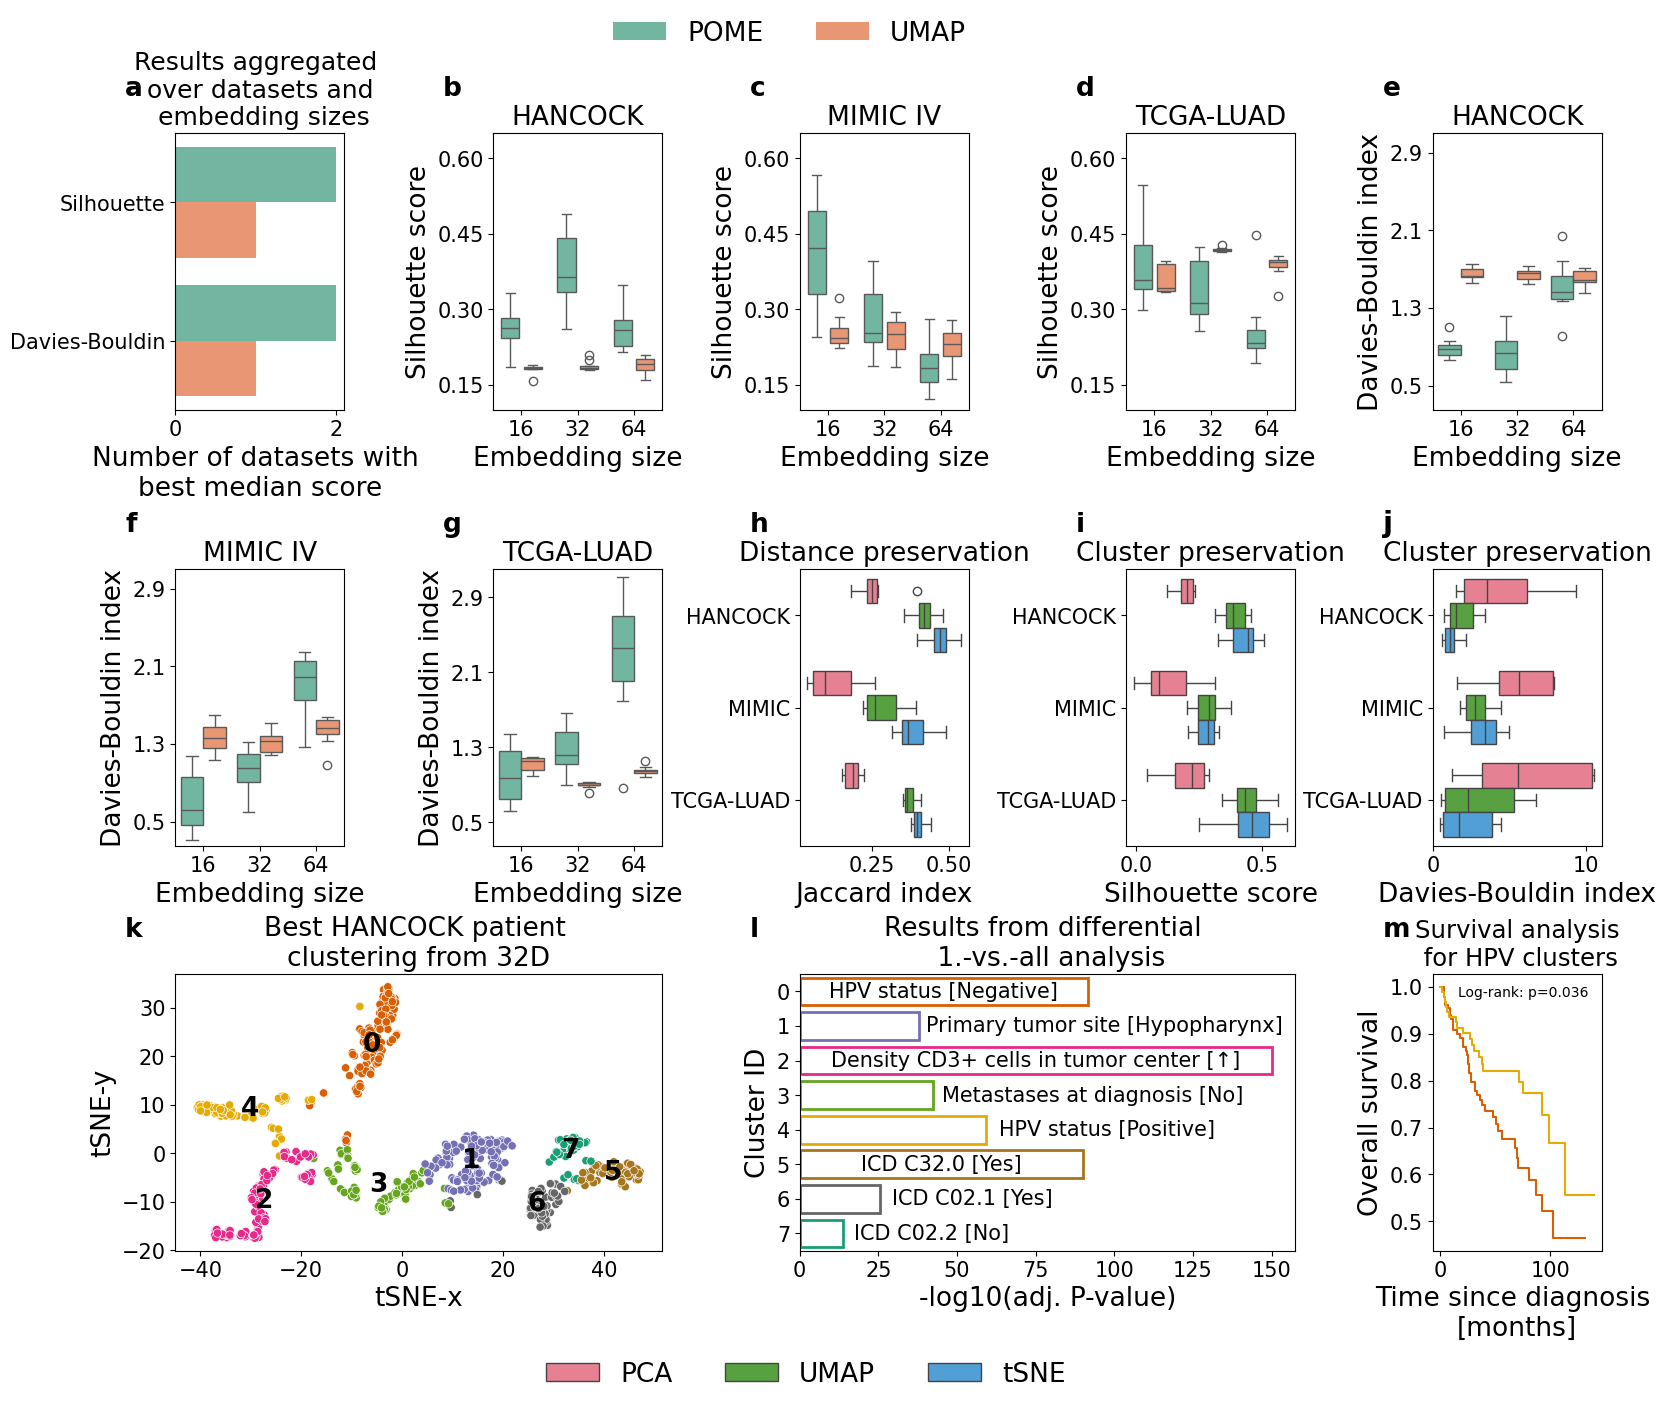

In [136]:
mosaic = [
['a', 'b', 'c', 'd', 'e'], ['f', 'g', 'h', 'i', 'j'], ['k', 'k', 'l', 'l', 'm']
]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(16,13), layout='constrained')

X=1
labelfontsize = 20-X
titlefontsize = 20-X
ticklabelsize = 16-X
xylabelsize = 18-X
legendfontsize = 16-X
legendtitlefontsize = 18-X
offset = transforms.ScaledTranslation(-36 / 72, 27 / 72, fig.dpi_scale_trans)

sns.barplot(data=aggregated_df, y="score", x="max_on_dataset",
             hue="Method", ax=axes['a'],
             legend=True, palette=sns.color_palette("Set2"))
axes['a'].set_ylabel('', fontsize=labelfontsize) 
axes['a'].set_xlabel('Number of datasets with \nbest median score', fontsize=labelfontsize) 
axes['a'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['a'].tick_params(axis='y', labelsize=ticklabelsize) 
#axes['a'].set_yticks([0.0, 1.0, 2.0])
#axes['a'].set_ylim(0.1, 0.65)
axes['a'].set_title("Results aggregated \n over datasets and \n embedding sizes", fontsize=titlefontsize-1)
axes['a'].text(0.0, 1.0, 'a', transform=axes['a'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

handles, labels = axes["a"].get_legend_handles_labels()
axes["a"].legend_.remove()

legend1 = fig.legend(
    handles, labels,
    loc="center",
    bbox_to_anchor=(0.49, 1.01),   # adjust this value
    ncol=len(labels),
    fontsize=legendfontsize+4,
    frameon=False
)

sns.boxplot(data=all[all["Dataset"]=="HANCOCK"], x="dim", y="silhouette",
             hue="Method", ax=axes['b'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette("Set2"))
axes['b'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['b'].set_ylabel('Silhouette score', fontsize=labelfontsize) 
axes['b'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['b'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['b'].set_yticks([0.15, 0.3, 0.45, 0.6])
axes['b'].set_ylim(0.1, 0.65)
axes['b'].set_title("HANCOCK", fontsize=titlefontsize)
axes['b'].text(0.0, 1.0, 'b', transform=axes['b'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.boxplot(data=all[all["Dataset"]=="MIMIC"], x="dim", y="silhouette",
             hue="Method", ax=axes['c'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette("Set2"))
axes['c'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['c'].set_ylabel('Silhouette score', fontsize=labelfontsize) 
axes['c'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['c'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['c'].set_yticks([0.15, 0.3, 0.45, 0.6])
axes['c'].set_ylim(0.1, 0.65)
axes['c'].set_title("MIMIC IV", fontsize=titlefontsize)
axes['c'].text(0.0, 1.0, 'c', transform=axes['c'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.boxplot(data=all[all["Dataset"]=="TCGA-LUAD"], x="dim", y="silhouette",
             hue="Method", ax=axes['d'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette("Set2"))
axes['d'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['d'].set_ylabel('Silhouette score', fontsize=labelfontsize) 
axes['d'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['d'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['d'].set_yticks([0.15, 0.3, 0.45, 0.6])
axes['d'].set_ylim(0.1, 0.65)
axes['d'].set_title("TCGA-LUAD", fontsize=titlefontsize)
axes['d'].text(0.0, 1.0, 'd', transform=axes['d'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.boxplot(data=all[all["Dataset"]=="HANCOCK"], x="dim", y="db_final",
             hue="Method", ax=axes["e"], legend=False, palette=sns.color_palette("Set2"))
axes['e'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['e'].set_ylabel('Davies-Bouldin index', fontsize=labelfontsize) 
axes['e'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['e'].tick_params(axis='y', labelsize=ticklabelsize)
axes['e'].set_yticks([0.5, 1.3, 2.1, 2.9])
axes['e'].set_ylim(0.25, 3.1)
axes['e'].set_title("HANCOCK", fontsize=titlefontsize)
axes['e'].text(0.0, 1.0, 'e', transform=axes['e'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.boxplot(data=all[all["Dataset"]=="MIMIC"], x="dim", y="db_final",
             hue="Method", ax=axes["f"], legend=False, palette=sns.color_palette("Set2"))
axes['f'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['f'].set_ylabel('Davies-Bouldin index', fontsize=labelfontsize) 
axes['f'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['f'].tick_params(axis='y', labelsize=ticklabelsize)
axes['f'].set_yticks([0.5, 1.3, 2.1, 2.9])
axes['f'].set_ylim(0.25, 3.1)
axes['f'].set_title("MIMIC IV", fontsize=titlefontsize)
axes['f'].text(0.0, 1.0, 'f', transform=axes['f'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.boxplot(data=all[all["Dataset"]=="TCGA-LUAD"], x="dim", y="db_final",
             hue="Method", ax=axes["g"], legend=False, palette=sns.color_palette("Set2"))
axes['g'].set_xlabel('Embedding size', fontsize=labelfontsize) 
axes['g'].set_ylabel('Davies-Bouldin index', fontsize=labelfontsize) 
axes['g'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['g'].tick_params(axis='y', labelsize=ticklabelsize)
axes['g'].set_yticks([0.5, 1.3, 2.1, 2.9])
axes['g'].set_ylim(0.25, 3.2)
axes['g'].set_title("TCGA-LUAD", fontsize=titlefontsize)
axes['g'].text(0.0, 1.0, 'g', transform=axes['g'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.boxplot(data=mean_dist_df, x="jaccard_index", y="dataset",
             hue="method", ax=axes["h"], legend=True, palette=sns.color_palette("husl", 3))
axes['h'].set_xlabel('Jaccard index', fontsize=labelfontsize) 
axes['h'].set_ylabel('', fontsize=labelfontsize) 
axes['h'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['h'].tick_params(axis='y', labelsize=ticklabelsize)
axes['h'].text(0.0, 1.0, 'h', transform=axes['h'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')
axes['h'].set_title("Distance preservation", fontsize=titlefontsize)

handles2, labels2 = axes["h"].get_legend_handles_labels()
axes["h"].legend_.remove()
legend2 = fig.legend(
    handles2, labels2,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),   # adjust vertically if needed
    ncol=len(labels2),
    fontsize=legendfontsize+4,
    frameon=False
)

sns.boxplot(data=silhouette_df, x="silhouette", y="dataset",
             hue="method", ax=axes["i"], legend=False, palette=sns.color_palette("husl", 3), showfliers=False)
axes['i'].set_xlabel('Silhouette score', fontsize=labelfontsize) 
axes['i'].set_ylabel('', fontsize=labelfontsize) 
axes['i'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['i'].tick_params(axis='y', labelsize=ticklabelsize)
axes['i'].set_title("Cluster preservation", fontsize=titlefontsize)
axes['i'].text(0.0, 1.0, 'i', transform=axes['i'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.boxplot(data=davies_df, x="davies_bouldin", y="dataset",
             hue="method", ax=axes["j"], legend=False, palette=sns.color_palette("husl", 3), showfliers=False)
axes['j'].set_xlabel('Davies-Bouldin index', fontsize=labelfontsize) 
axes['j'].set_ylabel('', fontsize=labelfontsize) 
axes['j'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['j'].tick_params(axis='y', labelsize=ticklabelsize)
axes['j'].set_title("Cluster preservation", fontsize=titlefontsize)
axes['j'].text(0.0, 1.0, 'j', transform=axes['j'].transAxes + offset, fontsize=labelfontsize+2, fontweight='bold')

# color palette
colors = [sns.color_palette("Dark2", 9)[1], sns.color_palette("Dark2", 9)[5]]
ax = axes['m']
for cluster, color in zip([0,4], colors):
    cluster_df = targets_df[targets_df["cluster_id"] == cluster].copy()

    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=cluster_df["followup_months"],
        event_observed=cluster_df["survival_status"],
        #label=f"Cluster {cluster}"
    )

    kmf.plot(
        ax=ax,
        ci_show=False,
        show_censors=False,
        color=color
    )
ax.set_ylabel("Overall survival", fontsize=labelfontsize)
ax.set_xlabel("Time since diagnosis \n[months]", fontsize=labelfontsize)
ax.set_title("Survival analysis\n for HPV clusters", fontsize=titlefontsize-1.5)
axes['m'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['m'].tick_params(axis='y', labelsize=ticklabelsize)
ax.legend().remove()
#ax.legend(title="Cluster")
axes['m'].text(0.0, 1.0, 'm', transform=axes['m'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

cluster0 = targets_df[targets_df["cluster_id"] == 0]
cluster4 = targets_df[targets_df["cluster_id"] == 4]
results = logrank_test(
    cluster0["followup_months"],
    cluster4["followup_months"],
    event_observed_A=cluster0["survival_status"],
    event_observed_B=cluster4["survival_status"]
)
p = results.p_value
ax.text(0.15, 0.92, f"Log-rank: p={p:.3f}", transform=ax.transAxes)

# scatter
sns.scatterplot(
    data=vis_df, x="tSNE_1", y="tSNE_2",
    hue="cluster_id",
    ax=axes["k"], legend=False,
    palette=sns.color_palette("Dark2", 9)[1:]
)

# compute cluster centroids
centroids = (
    vis_df.groupby("cluster_id")[["tSNE_1", "tSNE_2"]]
    .mean()
    .reset_index()
)

# annotate clusters
for _, row in centroids.iterrows():
    axes["k"].text(
        row["tSNE_1"], row["tSNE_2"],
        str(int(row["cluster_id"])),
        ha="center", va="center",
        fontsize=labelfontsize,
        fontweight="bold",
        #bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1)
    )

axes['k'].set_xlabel('tSNE-x', fontsize=labelfontsize) 
axes['k'].set_ylabel('tSNE-y', fontsize=labelfontsize) 
axes['k'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['k'].tick_params(axis='y', labelsize=ticklabelsize)
axes['k'].set_title("Best HANCOCK patient \nclustering from 32D", fontsize=titlefontsize)
axes['k'].text(0.0, 1.0, 'k', transform=axes['k'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

copied_pval_df = cluster_pval_df.copy()
copied_pval_df["cluster_id"] = copied_pval_df["cluster_id"].astype("str")

sns.barplot(
    data=copied_pval_df,
    x="neglog10_adj",
    y="cluster_id",
    ax=axes["l"],
    color="none",
    legend=False
)

palette = sns.color_palette("Dark2", 9)[1:]
cluster_ids = copied_pval_df["cluster_id"].unique()
cluster_to_idx = {cid: i for i, cid in enumerate(cluster_ids)}

# style bars
for bar, cid in zip(axes["l"].patches, copied_pval_df["cluster_id"]):
    bar.set_facecolor("none")
    bar.set_edgecolor(palette[cluster_to_idx[cid]])
    bar.set_linewidth(2)

# write variable labels inside bars
hpv_counter = 0
deduce_size = 0
for bar, label in zip(axes["l"].patches, copied_pval_df["value"]):
    if label.startswith("Primary tumor site"):
        width = bar.get_width()
        y = bar.get_y() + bar.get_height()/2
        axes["l"].text(
            width*0.5+78, y, label,
            ha="center", va="center",
            fontsize=ticklabelsize-deduce_size
        )
    elif label.startswith("Metastases at"):
        width = bar.get_width()
        y = bar.get_y() + bar.get_height()/2
        axes["l"].text(
            width*0.5+72, y, label,
            ha="center", va="center",
            fontsize=ticklabelsize-deduce_size
        )
    elif label.startswith("HPV"):
        if hpv_counter == 1:
            width = bar.get_width()
            y = bar.get_y() + bar.get_height()/2
            axes["l"].text(
                width*0.5+68, y, label,
                ha="center", va="center",
                fontsize=ticklabelsize-deduce_size
            )
        else:
            hpv_counter += 1
            width = bar.get_width()
            y = bar.get_y() + bar.get_height()/2
            axes["l"].text(
                width*0.5, y, label,
                ha="center", va="center",
                fontsize=ticklabelsize-deduce_size
            )
    elif label.startswith("ICD C02.1"):
        width = bar.get_width()
        y = bar.get_y() + bar.get_height()/2
        axes["l"].text(
            width*0.5+42, y, label,
            ha="center", va="center",
            fontsize=ticklabelsize-deduce_size
        )
    elif label.startswith("ICD C02.2"):
        width = bar.get_width()
        y = bar.get_y() + bar.get_height()/2
        axes["l"].text(
            width*0.5+35, y, label,
            ha="center", va="center",
            fontsize=ticklabelsize-deduce_size
        )
    else:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height()/2
        axes["l"].text(
            width*0.5, y, label,
            ha="center", va="center",
            fontsize=ticklabelsize-deduce_size
        )

# colorbar
cmap = mpl.colors.ListedColormap(palette[:len(cluster_ids)])
norm = mpl.colors.BoundaryNorm(np.arange(len(cluster_ids)+1)-0.5, cmap.N)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

axes['l'].set_xlabel('-log10(adj. P-value)', fontsize=labelfontsize) 
axes['l'].set_ylabel('Cluster ID', fontsize=labelfontsize) 
axes['l'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['l'].tick_params(axis='y', labelsize=ticklabelsize)
axes['l'].set_title("Results from differential \n 1.-vs.-all analysis", fontsize=titlefontsize)
axes['l'].text(0.0, 1.0, 'l', transform=axes['l'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

plt.savefig("unsupervised_clustering_and_visualization.pdf", bbox_inches='tight', bbox_extra_artists=[legend1, legend2])